In [6]:
import pandas as pd

# Load the uploaded CSV file to a DataFrame
file_path = r'data/Wholesale customers data.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


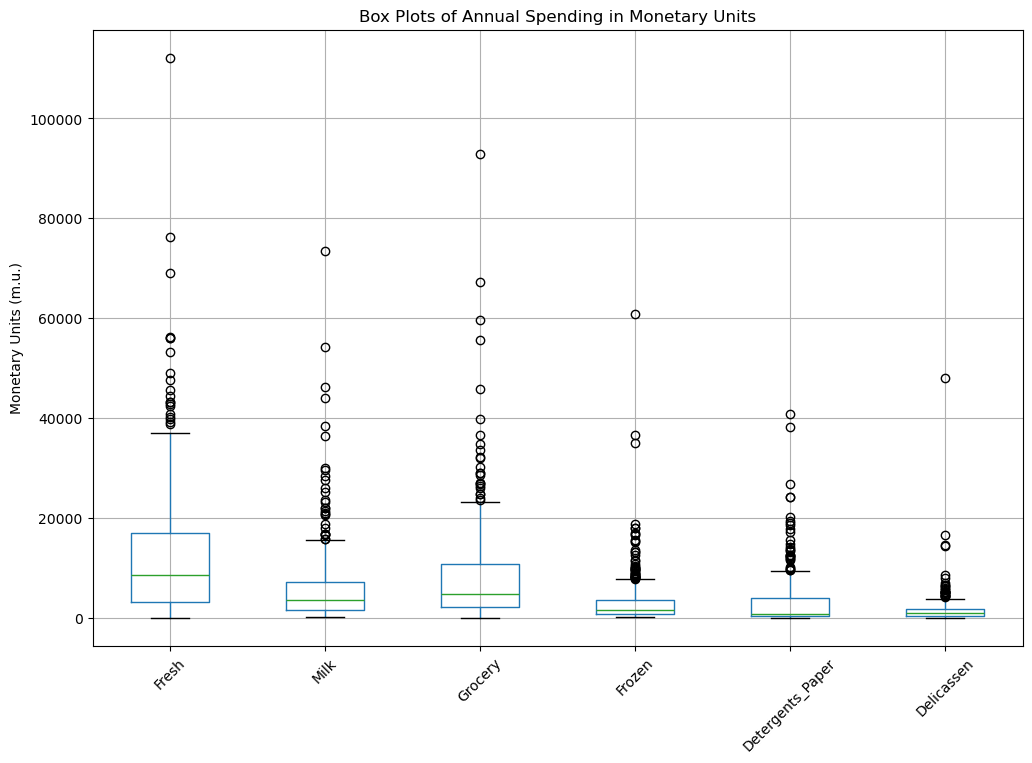

In [7]:
import matplotlib.pyplot as plt

# Select the columns with monetary unit data
monetary_columns = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Create box plots for these columns
plt.figure(figsize=(12, 8))
data[monetary_columns].boxplot()
plt.title('Box Plots of Annual Spending in Monetary Units')
plt.ylabel('Monetary Units (m.u.)')
plt.xticks(rotation=45)
plt.show()

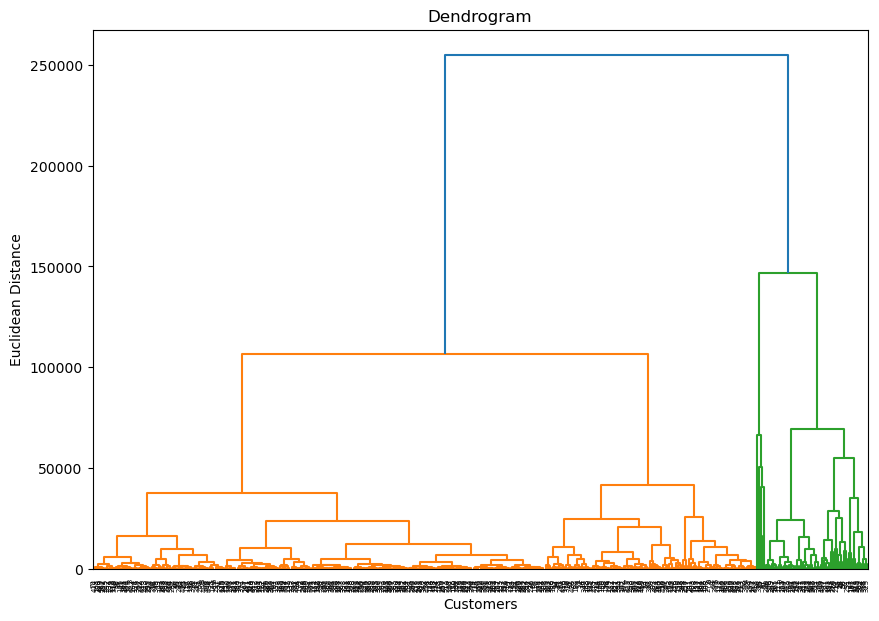

In [8]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import numpy as np

# Select the 'Milk' and 'Grocery' columns for clustering
clustering_data = data[['Milk', 'Grocery']]

# Step 1: Use a dendrogram to find the optimal number of clusters
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(clustering_data, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

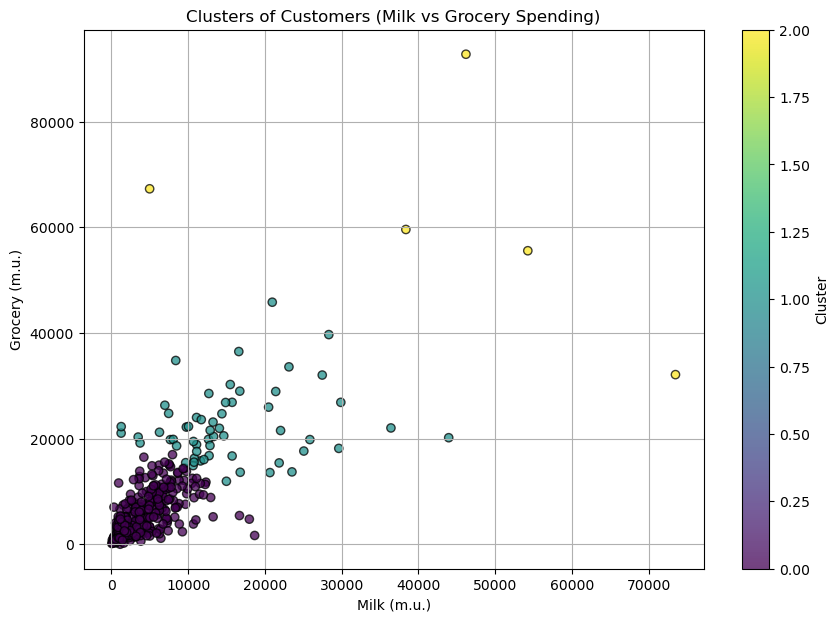

Cluster Summary:
                 Milk       Grocery
Cluster                            
0         3840.490716   5035.689655
1        15261.879310  22288.724138
2        43460.600000  61472.200000


In [9]:
# Step 2: Perform Agglomerative Clustering
# Using 3 clusters as identified from the dendrogram
model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
cluster_labels = model.fit_predict(clustering_data)

# Add cluster labels to the original data
data['Cluster'] = cluster_labels

# Visualizing the clusters
plt.figure(figsize=(10, 7))
plt.scatter(data['Milk'], data['Grocery'], c=data['Cluster'], cmap='viridis', edgecolor='k', alpha=0.75)
plt.title('Clusters of Customers (Milk vs Grocery Spending)')
plt.xlabel('Milk (m.u.)')
plt.ylabel('Grocery (m.u.)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

# Descriptive statistics of each cluster
cluster_summary = data.groupby('Cluster')[['Milk', 'Grocery']].mean()
print("Cluster Summary:")
print(cluster_summary)